In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [25]:
def compute_vector_length(vector):
    norm = np.sqrt(np.sum([v ** 2 for v in vector]))

    return norm
vector = np.array([-2, 4, 9, 21])
result = compute_vector_length(vector)
print(round(result, 2))

23.28


In [ ]:
def compute_eigenvalues_eigenvectors(matrix):
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    return eigenvalues, eigenvectors

matrix = np.array([
    [0.9, 0.2],
    [0.1, 0.8]
])
eigenvalues, eigenvectors = compute_eigenvalues_eigenvectors(matrix)
print(eigenvalues)
print(eigenvectors)

#Tim hieu LSA: Latent semantic analysis
#Compression Image

[1.  0.7]
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]


In [47]:
def compute_cosine_sim(v1, v2):
    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return cos_sim
v1 = np.array([1000000000, 10, -400000000])
v2 = np.array([1, 2, 3])
result = compute_cosine_sim(v1, v2)
print(result)

-0.04962916173562984


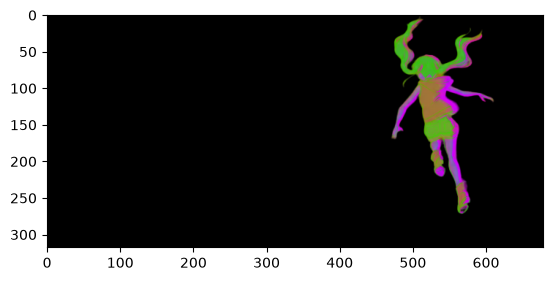

In [139]:
background_image = cv2.imread('Exercise04_Data/GreenBackground.png', 1)
object_image = cv2.imread("Exercise04_Data/Object.png", 1)
target_background_image = cv2.imread('Exercise04_Data/NewBackground.jpg', 1)



# Resize
IMAGE_SIZE = (678, 318)
background_image = cv2.resize(background_image, IMAGE_SIZE)
object_image = cv2.resize(object_image, IMAGE_SIZE)
target_background_image = cv2.resize(target_background_image, IMAGE_SIZE)

#Compute Differences

differences = cv2.absdiff(background_image, object_image)
plt.imshow(differences)

(318, 678)


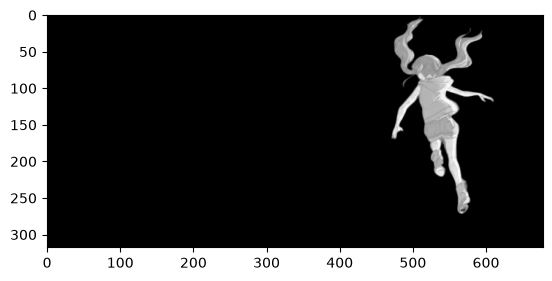

In [142]:
#GrayScales
differences_single = differences.sum(axis = 2) / 3

print(differences_single.shape)

plt.imshow(differences_single, cmap = 'gray')

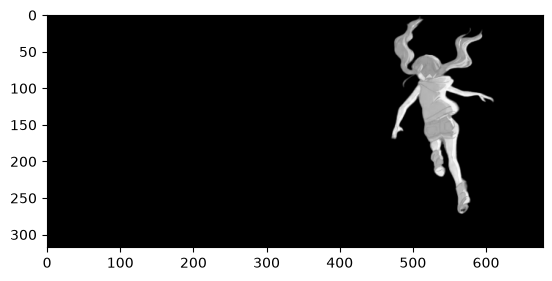

In [150]:
differences_single = differences_single.astype(np.uint8)
plt.imshow(differences_single, cmap = 'gray')

(318, 678)


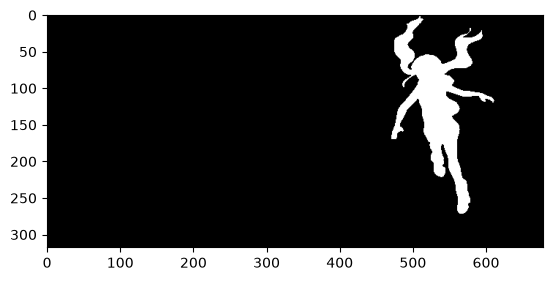

In [153]:
#Convert to Binary Image
binary_image = np.where(differences_single >= 15, 255, 0)
print(binary_image.shape)
plt.imshow(binary_image, cmap = 'gray')

In [154]:
#Reshape 2D -> 3D

binary_image = np.stack((binary_image, ) * 3, axis = -1)

print(binary_image.shape)

(318, 678, 3)


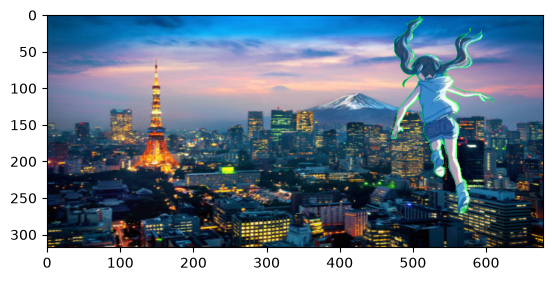

In [155]:
#Result
output = np.where(binary_image == 255, object_image, target_background_image)
plt.imshow(output[:, :, ::-1])